# SafeGuard AI — Detección de EPIs en Obras

**Dataset:** Construction Site Safety (Roboflow / Kaggle) — 2.801 imágenes, 10 clases  
**Modelos:** SSD300-VGG16 (fine-tuning desde backbone ImageNet) vs YOLOv8n (fine-tuning desde COCO)

> Ambos modelos parten de pesos preentrenados → comparación justa por transfer learning.

### Arquitecturas comparadas
| Modelo | Backbone inicial | Cabeza | Estrategia |
|--------|-----------------|--------|------------|
| **SSD300-VGG16** | VGG16 (ImageNet) | SSD head (aleatoria) | Fine-tuning LR diferenciado |
| **YOLOv8n** | YOLOv8n (COCO) | Detection head | Fine-tuning 100 épocas |

### Estructura del proyecto
```
seguridad_obra/
├── main.ipynb              ← este notebook
├── colab_train.ipynb       ← fine-tuning SSD en Google Colab (GPU)
├── data/
│   ├── css-data/           ← dataset principal (train/valid/test)
│   ├── results_yolov8n_100e/  ← best.pt YOLOv8 ya entrenado
│   └── source_files/       ← vídeos e imágenes de prueba
├── modelos/
│   ├── config.py           ← rutas, clases, hiperparámetros
│   ├── dataset.py          ← carga dataset para SSD
│   ├── train_ssd.py        ← fine-tuning SSD300 (backbone ImageNet + early stopping)
│   ├── train_yolo.py       ← entrenamiento/fine-tuning YOLOv8
│   └── evaluate.py         ← métricas y comparación
└── webcam/
    └── pipeline.py         ← detección en tiempo real
```

### Clases detectadas (5 relevantes para seguridad laboral)
| ID | Clase | Descripción |
|----|-------|-------------|
| 1 | helmet | Casco de protección |
| 2 | no-helmet | Persona sin casco |
| 3 | vest | Chaleco reflectante |
| 4 | no-vest | Persona sin chaleco |
| 5 | person | Persona detectada |

In [19]:
import sys
from pathlib import Path
import importlib, subprocess, sys
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import cv2
from collections import Counter
import random
from modelos.train_ssd import build_ssd_model, train_ssd, load_checkpoint
from modelos.dataset import get_test_dataset
from modelos.train_yolo import generate_data_yaml, build_yolo_model, train_yolo
from modelos.evaluate import (
    evaluate_ssd, evaluate_yolo, compute_metrics, print_metrics, compare_models
)
from webcam.pipeline import run_webcam

## 0. Setup

In [20]:
_search = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
PROJECT_ROOT = next(
    (p for p in _search if (p / "modelos" / "config.py").exists()),
    Path.cwd()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Raíz del proyecto: {PROJECT_ROOT}")
assert (PROJECT_ROOT / "modelos" / "config.py").exists(), (
    "ERROR: No se encuentra modelos/config.py\n"
    "Abre Jupyter desde la carpeta seguridad_obra/"
)

Raíz del proyecto: c:\Users\oriol\OneDrive\Escritorio\Master\imagenes\seguridad_obra


In [21]:
def _pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip"] + list(args) + ["-q"])

_torch_ok = importlib.util.find_spec("torch") is not None
_tv_ok    = importlib.util.find_spec("torchvision") is not None

if not _torch_ok or not _tv_ok:
    print("Instalando torch + torchvision (CPU)...")
    _pip("install", "torch", "torchvision", "--index-url", "https://download.pytorch.org/whl/cpu")
else:
    import torch, torchvision
    tv_minor = int(torchvision.__version__.split(".")[1])
    t_minor  = int(torch.__version__.split(".")[1])
    if tv_minor != t_minor + 15:
        print(f"Incompatibles: torch {torch.__version__} + torchvision {torchvision.__version__}")
        _pip("uninstall", "torch", "torchvision", "-y")
        _pip("install", "torch", "torchvision", "--index-url", "https://download.pytorch.org/whl/cpu")
        print("✓ Reinstalados — REINICIA EL KERNEL y vuelve a ejecutar")
    else:
        print(f"✓ torch {torch.__version__} + torchvision {torchvision.__version__} OK")

_others = {"cv2": "opencv-python", "PIL": "pillow",
           "matplotlib": "matplotlib", "numpy": "numpy",
           "ultralytics": "ultralytics", "yaml": "pyyaml"}
_missing = [pkg for mod, pkg in _others.items() if importlib.util.find_spec(mod) is None]
if _missing:
    print(f"Instalando: {_missing}")
    _pip("install", *_missing)

print("✓ Dependencias listas")

✓ torch 2.12.0+cpu + torchvision 0.27.0+cpu OK
✓ Dependencias listas


In [22]:
from modelos.config import (
    BASE_DIR, DATA_DIR, CHECKPOINTS_DIR, OUTPUTS_DIR, LOGS_DIR,
    YOLO_PRETRAINED, DATA_YAML,
    SSD_CLASS_NAMES, YOLO_CLASS_NAMES,
    SCORE_THRESHOLD, IOU_THRESHOLD,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo:       {device}")
print(f"PyTorch:           {torch.__version__}")
print(f"Dataset:           {DATA_DIR}")
print(f"YOLOv8 disponible: {YOLO_PRETRAINED.exists()}")
print(f"SSD checkpoint:    {(CHECKPOINTS_DIR / 'ssd_best.pth').exists()}")

Dispositivo:       cpu
PyTorch:           2.12.0+cpu
Dataset:           c:\Users\oriol\OneDrive\Escritorio\Master\imagenes\seguridad_obra\data\css-data
YOLOv8 disponible: True
SSD checkpoint:    True


---
## 1. Exploración del Dataset

In [23]:
for split in ["train", "valid", "test"]:
    n_imgs = len(list((DATA_DIR / split / "images").glob("*.jpg")))
    n_lbls = len(list((DATA_DIR / split / "labels").glob("*.txt")))
    print(f"{split:>6}: {n_imgs:4d} imágenes | {n_lbls:4d} labels")

 train: 2605 imágenes | 2605 labels
 valid:  114 imágenes |  114 labels
  test:   82 imágenes |   82 labels


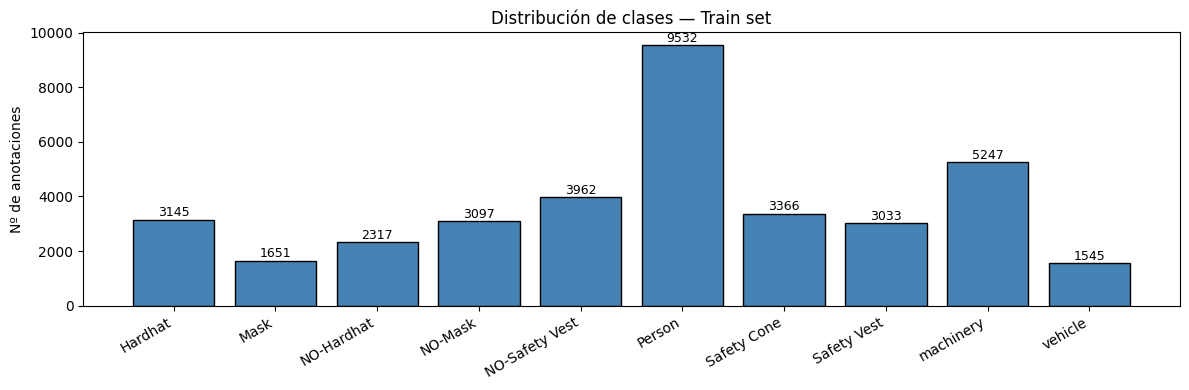

In [24]:
def count_classes(split):
    counter = Counter()
    for lbl in (DATA_DIR / split / "labels").glob("*.txt"):
        with open(lbl) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counter[int(parts[0])] += 1
    return counter

train_counts     = count_classes("train")
class_names_list = [YOLO_CLASS_NAMES[i] for i in range(10)]
counts           = [train_counts.get(i, 0) for i in range(10)]

plt.figure(figsize=(12, 4))
bars = plt.bar(class_names_list, counts, color="steelblue", edgecolor="black")
plt.title("Distribución de clases — Train set")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Nº de anotaciones")
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

C:\Users\oriol\AppData\Local\Temp\ipykernel_11076\2948880691.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", 10)


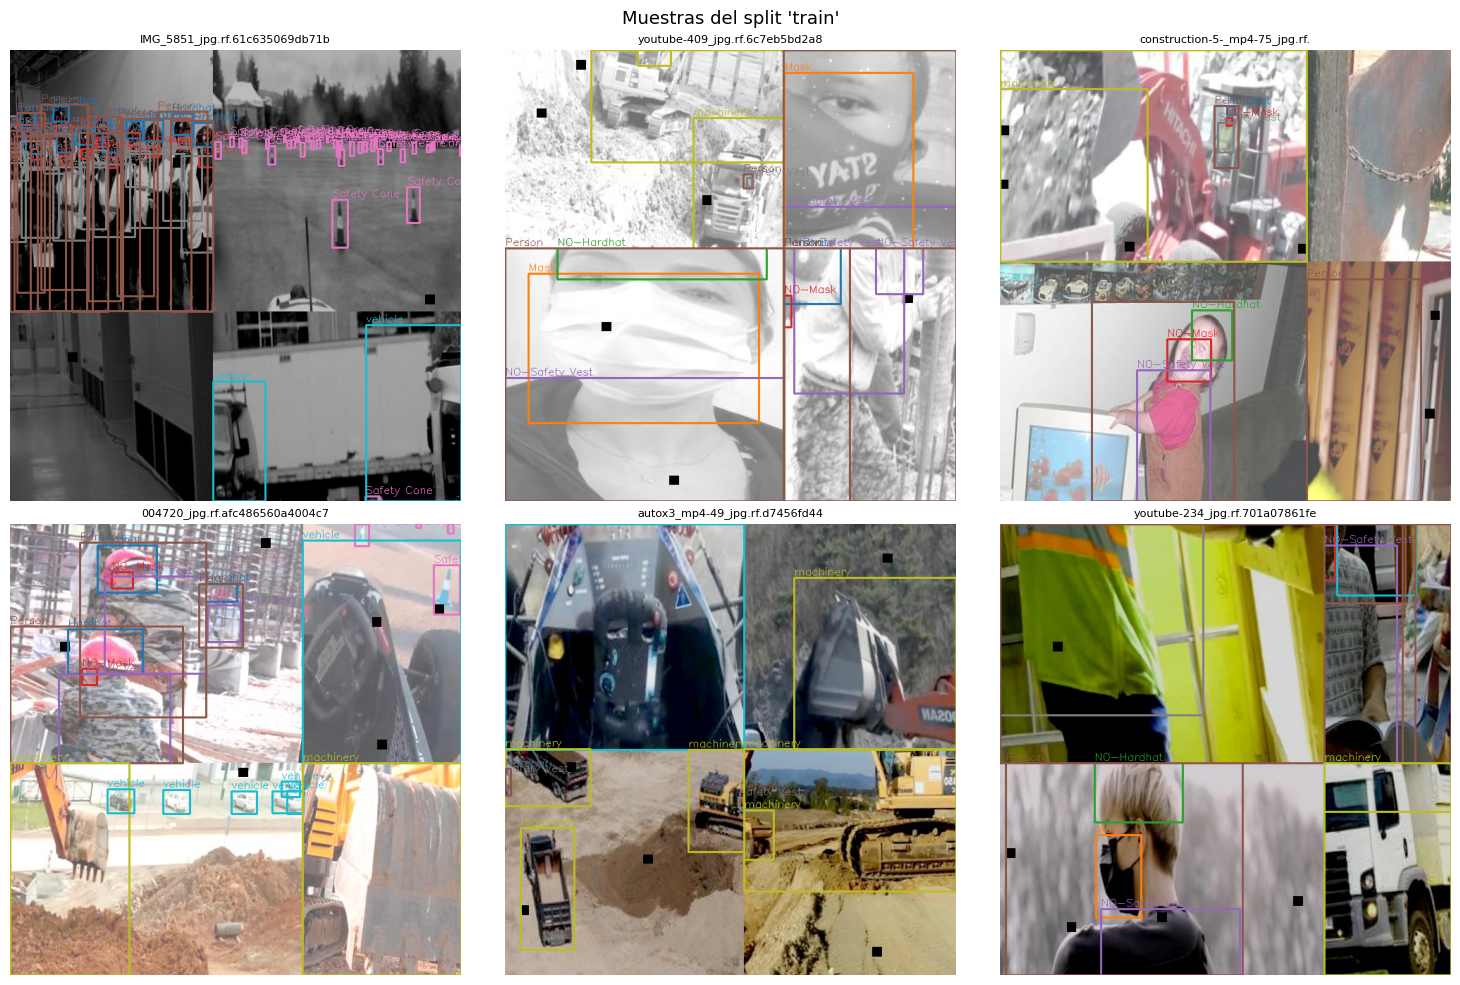

In [25]:
def visualize_samples(split="train", n=6):
    imgs_dir = DATA_DIR / split / "images"
    lbls_dir = DATA_DIR / split / "labels"
    samples  = random.sample(list(imgs_dir.glob("*.jpg")), min(n, len(list(imgs_dir.glob("*.jpg")))))
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()
    colors = plt.cm.get_cmap("tab10", 10)
    for ax, img_path in zip(axes, samples):
        img  = np.array(Image.open(img_path).convert("RGB"))
        h, w = img.shape[:2]
        lbl_p = lbls_dir / img_path.with_suffix(".txt").name
        if lbl_p.exists():
            with open(lbl_p) as f:
                for line in f:
                    parts = line.strip().split()
                    if not parts: continue
                    cls_id = int(parts[0])
                    xc, yc, bw, bh = map(float, parts[1:5])
                    x1 = int((xc-bw/2)*w); y1 = int((yc-bh/2)*h)
                    x2 = int((xc+bw/2)*w); y2 = int((yc+bh/2)*h)
                    color = tuple(int(c*255) for c in colors(cls_id)[:3])
                    cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
                    cv2.putText(img, YOLO_CLASS_NAMES.get(cls_id, str(cls_id)),
                                (x1, max(0,y1-4)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
        ax.imshow(img)
        ax.set_title(img_path.name[:30], fontsize=8)
        ax.axis("off")
    for ax in axes[len(samples):]: ax.axis("off")
    plt.suptitle(f"Muestras del split '{split}'", fontsize=13)
    plt.tight_layout(); plt.show()

visualize_samples("train", n=6)

---
## 2. Fine-tuning SSD300-VGG16

**Configuración del entrenamiento (ejecutado en `colab_train.ipynb`):**

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| Backbone | VGG16 (ImageNet) | Transfer learning — características visuales ya aprendidas |
| LR cabeza | Optuna `[1e-4, 1e-2]` | Cabeza inicializada aleatoriamente, necesita aprender |
| LR backbone | LR × 0.1 | Ya preentrenado, solo ajuste fino |
| Épocas máx. | 100 | Techo con early stopping |
| Early stopping | patience=10 | Para si 10 épocas sin mejorar `val_loss` |
| Scheduler | MultiStepLR (×0.1 en é40 y é70) | Reduce LR cuando el modelo comienza a estabilizarse |

**Preprocesamiento:**

| Transform | Split | Justificación |
|-----------|-------|---------------|
| RandomHorizontalFlip (p=0.5) | Solo train | Trabajadores en cualquier orientación horizontal |
| ColorJitter (br=0.3, ct=0.3, sat=0.2, hue=0.05) | Solo train | Iluminación variable en obras (amanecer, mediodía, focos) |
| GaussianBlur k=3 (p=0.2) | Solo train | Cámaras de baja resolución y desenfoque por movimiento |
| ToTensor | Train + val/test | PIL → tensor [0,1] |
| Normalización ImageNet | Interna al modelo | El modelo SSD la aplica automáticamente al usar backbone ImageNet |

> Para GPU usa `colab_train.ipynb` en Google Colab → descarga `ssd_best.pth` → pégalo en `modelos/checkpoints/`

In [26]:
ssd_checkpoint = CHECKPOINTS_DIR / "ssd_best.pth"
ssd_history    = None

if device.type == "cuda":
    _epochs, _batch, _patience = 50, 8, 10
else:
    _epochs, _batch, _patience = 15, 4, 5
    print(f"CPU detectada — máx {_epochs} épocas, batch={_batch}")
    print("Para GPU usa colab_train.ipynb en Google Colab")

if ssd_checkpoint.exists():
    print(f"Checkpoint encontrado: {ssd_checkpoint}")
    print("Entrenamiento omitido — cargando pesos guardados...")
    ssd_model = build_ssd_model().to(device)
    load_checkpoint(ssd_model, ssd_checkpoint, device=device)
    ssd_model.eval()
else:
    print("No se encontró checkpoint. Iniciando entrenamiento...")
    ssd_model, ssd_history = train_ssd(
        num_epochs=_epochs, batch_size=_batch, lr=0.005, patience=_patience
    )

CPU detectada — máx 15 épocas, batch=4
Para GPU usa colab_train.ipynb en Google Colab
Checkpoint encontrado: c:\Users\oriol\OneDrive\Escritorio\Master\imagenes\seguridad_obra\modelos\checkpoints\ssd_best.pth
Entrenamiento omitido — cargando pesos guardados...
Checkpoint cargado: epoca 32, val_loss=5.0863


In [27]:
if ssd_history is not None:
    stopped    = ssd_history["stopped_epoch"]
    best_epoch = ssd_history["val_loss"].index(min(ssd_history["val_loss"])) + 1
    best_loss  = min(ssd_history["val_loss"])
    plt.figure(figsize=(10, 4))
    plt.plot(range(1, stopped+1), ssd_history["train_loss"], label="Train Loss")
    plt.plot(range(1, stopped+1), ssd_history["val_loss"],   label="Val Loss")
    plt.axvline(x=best_epoch, color="green", linestyle="--", alpha=0.7,
                label=f"Mejor época ({best_epoch})")
    plt.scatter([best_epoch], [best_loss], color="green", zorder=5)
    plt.title(f"SSD300 — paró en época {stopped} | mejor val_loss={best_loss:.4f}")
    plt.xlabel("Época"); plt.ylabel("Loss")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
else:
    print("Modelo cargado desde checkpoint — no hay historial de entrenamiento.")

Modelo cargado desde checkpoint — no hay historial de entrenamiento.


---
## 3. Cargar YOLOv8n

El modelo YOLOv8n ya viene entrenado 100 épocas sobre este mismo dataset (`best.pt`).  
**Opción B** (comentada) permite hacer fine-tuning adicional si queremso (para comprar más adelante).

In [28]:
yaml_path = generate_data_yaml()
if YOLO_PRETRAINED.exists():
    yolo_model   = build_yolo_model(YOLO_PRETRAINED)
    yolo_weights = YOLO_PRETRAINED
    print(f"✓ YOLOv8n cargado desde: {YOLO_PRETRAINED}")
else:
    print(f"No encontrado: {YOLO_PRETRAINED}")

YAML generado en: c:\Users\oriol\OneDrive\Escritorio\Master\imagenes\seguridad_obra\modelos\ppe_data.yaml
✓ YOLOv8n cargado desde: c:\Users\oriol\OneDrive\Escritorio\Master\imagenes\seguridad_obra\data\results_yolov8n_100e\kaggle\working\runs\detect\train\weights\best.pt


In [29]:
# Opción B: fine-tuning adicional
# yolo_weights = train_yolo(
#     epochs=30,
#     from_pretrained=True,   # parte de best.pt ya disponible
#     data_yaml=yaml_path,
#     run_name="yolo_ft_30e",
# )
# yolo_model = build_yolo_model(yolo_weights)

---
## 4. Evaluación y Comparación de Modelos

In [30]:
# Evaluación SSD
# SCORE_THRESHOLD (0.40) está calibrado para YOLO preentrenado.
# SSD entrenado desde cero produce scores más bajos → usamos umbral propio.
SSD_SCORE_THRESHOLD = 0.10

test_ds    = get_test_dataset()
ssd_preds, ssd_targets = evaluate_ssd(ssd_model, test_ds, device, save_images=True)

all_scores = [s for pred in ssd_preds for s in pred["scores"].tolist()]
if all_scores:
    print(f"Predicciones totales (sin filtro): {len(all_scores)}")
    for thr in [0.40, 0.20, 0.10, 0.05]:
        print(f"  score >= {thr:.2f} : {sum(s >= thr for s in all_scores):4d} predicciones")
    print(f"  Mediana score  : {np.median(all_scores):.3f}")
    print(f"  Score máximo   : {max(all_scores):.3f}")
else:
    print("El modelo no produce ninguna predicción")

ssd_metrics = compute_metrics(
    ssd_preds, ssd_targets,
    score_threshold=SSD_SCORE_THRESHOLD, iou_threshold=IOU_THRESHOLD
)
print_metrics(ssd_metrics, f"SSD300-VGG16 (score>={SSD_SCORE_THRESHOLD})")


Inferencia SSD completada — 82 imágenes
Predicciones totales (sin filtro): 16400
  score >= 0.40 :  287 predicciones
  score >= 0.20 :  653 predicciones
  score >= 0.10 : 2549 predicciones
  score >= 0.05 : 10250 predicciones
  Mediana score  : 0.059
  Score máximo   : 0.997

───────────────────────────────────────────────────────
  SSD300-VGG16 (score>=0.1) — Precision / Recall por clase
───────────────────────────────────────────────────────
Clase         Precision     Recall     TP     FP     FN
───────────────────────────────────────────────────────
helmet           0.1975     0.5818     64    260     46
no-helmet        0.1429     0.4390     18    108     23
vest             0.2111     0.6885     42    157     19
no-vest          0.1582     0.5889     53    282     37
person           0.0665     0.5977    104   1461     70
───────────────────────────────────────────────────────
MEDIA            0.1552     0.5792


In [31]:
yolo_metrics = evaluate_yolo(
    weights_path=yolo_weights, data_yaml=yaml_path, split="test",
    score_threshold=SCORE_THRESHOLD, iou_threshold=IOU_THRESHOLD
)
print_metrics(yolo_metrics, "YOLOv8n")

Evaluación YOLO completada — 82 imágenes

───────────────────────────────────────────────────────
  YOLOv8n — Precision / Recall por clase
───────────────────────────────────────────────────────
Clase         Precision     Recall     TP     FP     FN
───────────────────────────────────────────────────────
helmet           0.9891     0.8273     91      1     19
no-helmet        0.8276     0.5854     24      5     17
vest             0.9455     0.8525     52      3      9
no-vest          0.9403     0.7000     63      4     27
person           0.9262     0.7931    138     11     36
───────────────────────────────────────────────────────
MEDIA            0.9257     0.7516


In [32]:
compare_models(ssd_metrics, yolo_metrics)


═══════════════════════════════════════════════════════════════════════════
  Comparación SSD300 vs YOLOv8n
═══════════════════════════════════════════════════════════════════════════
Clase         SSD Prec  SSD Rec  YOLOPrec  YOLORec   ΔPrec    ΔRec
──────────────────────────────────────────────────────────────────
helmet          0.1975   0.5818    0.9891   0.8273  +0.792  +0.245
no-helmet       0.1429   0.4390    0.8276   0.5854  +0.685  +0.146
no-vest         0.1582   0.5889    0.9403   0.7000  +0.782  +0.111
person          0.0665   0.5977    0.9262   0.7931  +0.860  +0.195
vest            0.2111   0.6885    0.9455   0.8525  +0.734  +0.164
──────────────────────────────────────────────────────────────────
MEDIA           0.1552   0.5792    0.9257   0.7516  +0.771  +0.172
═══════════════════════════════════════════════════════════════════════════


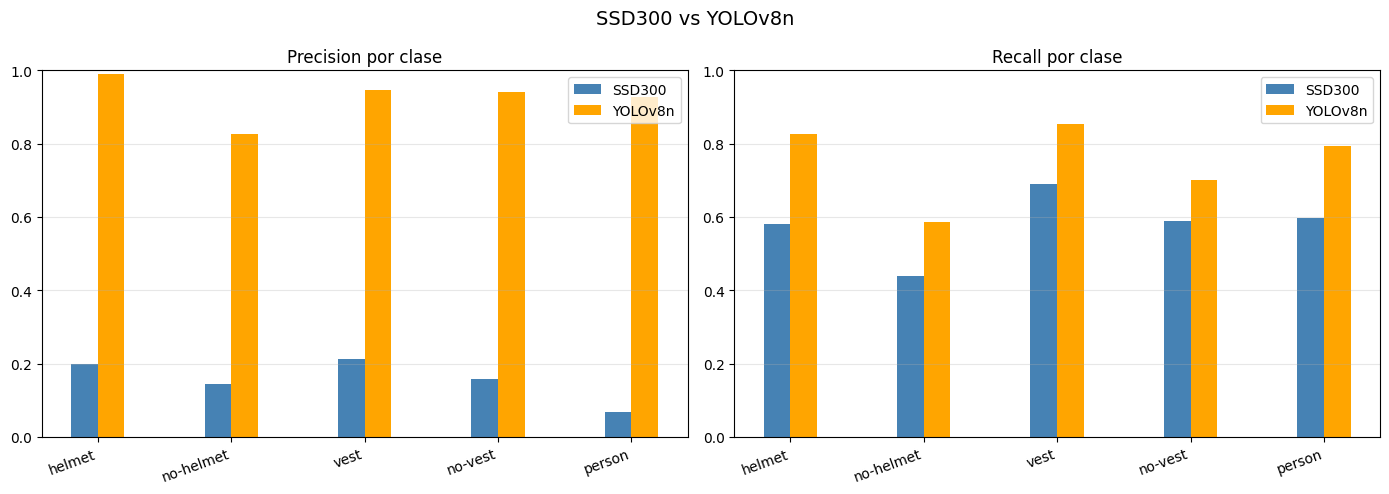

In [33]:
classes   = list(ssd_metrics.keys())
ssd_prec  = [ssd_metrics[c]["precision"]              for c in classes]
yolo_prec = [yolo_metrics.get(c,{}).get("precision",0) for c in classes]
ssd_rec   = [ssd_metrics[c]["recall"]                 for c in classes]
yolo_rec  = [yolo_metrics.get(c,{}).get("recall",0)   for c in classes]

x, w = np.arange(len(classes)), 0.2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, sv, yv, title in [(ax1,ssd_prec,yolo_prec,"Precision"),(ax2,ssd_rec,yolo_rec,"Recall")]:
    ax.bar(x-w/2, sv, w, label="SSD300",  color="steelblue")
    ax.bar(x+w/2, yv, w, label="YOLOv8n", color="orange")
    ax.set_xticks(x); ax.set_xticklabels(classes, rotation=20, ha="right")
    ax.set_ylim(0,1); ax.set_title(f"{title} por clase")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.suptitle("SSD300 vs YOLOv8n", fontsize=14)
plt.tight_layout(); plt.show()

---
## 5. Demo en Tiempo Real (Webcam / Vídeo)

> Pulsa **Q** para cerrar la ventana.  
> Los logs de infracciones se guardan en `outputs/logs/`.

In [34]:
run_webcam(model_type="yolo", weights_path=YOLO_PRETRAINED, source=0)

Dispositivo: cpu | Modelo: YOLO
Pipeline activo (YOLO). Pulsa 'Q' para salir.
Log guardado en: c:\Users\oriol\OneDrive\Escritorio\Master\imagenes\seguridad_obra\outputs\logs\infractions_20260528_170641.csv


In [35]:
"""
source_dir  = BASE_DIR / "data" / "source_files" / "source_files"
test_videos = list(source_dir.glob("*.mp4"))
print("Vídeos disponibles:")
for i, v in enumerate(test_videos):
    print(f"  [{i}] {v.name}")

if test_videos:
    run_webcam(model_type="yolo", weights_path=YOLO_PRETRAINED, source=str(test_videos[0])) 
"""

'\nsource_dir  = BASE_DIR / "data" / "source_files" / "source_files"\ntest_videos = list(source_dir.glob("*.mp4"))\nprint("Vídeos disponibles:")\nfor i, v in enumerate(test_videos):\n    print(f"  [{i}] {v.name}")\n\nif test_videos:\n    run_webcam(model_type="yolo", weights_path=YOLO_PRETRAINED, source=str(test_videos[0])) \n'

In [36]:
ssd_ckpt = CHECKPOINTS_DIR / "ssd_best.pth"
if ssd_ckpt.exists():
    run_webcam(model_type="ssd", weights_path=ssd_ckpt, source=0)
else:
    print(f"Checkpoint SSD no encontrado en {ssd_ckpt}")
    print("Entrena primero en la sección 2, o usa colab_train.ipynb con GPU.")

Dispositivo: cpu | Modelo: SSD
Checkpoint cargado: epoca 32, val_loss=5.0863
Pipeline activo (SSD). Pulsa 'Q' para salir.
Log guardado en: c:\Users\oriol\OneDrive\Escritorio\Master\imagenes\seguridad_obra\outputs\logs\infractions_20260528_170712.csv


---
## 6. SSD con Tracking + Inferencia Selectiva

**Problema:** El modelo SSD en CPU es lento → la cámara se ve entrecortada.  
**Solución:** Ejecutar SSD solo cada `inference_interval` frames y usar un tracker ligero en los intermedios.

| Frame | ¿Qué ocurre? | Coste |
|-------|-------------|-------|
| 0, 5, 10, … | SSD corre → detecciones reales | Alto (inferencia) |
| 1, 2, 3, 4 | Tracker mantiene posiciones e IDs | Casi nulo |

### Mejoras respecto al SSD estándar (sección 5)
- **FPS fluido** — la ventana se actualiza cada frame aunque el modelo no corra.
- **IDs por persona** — cada trabajador tiene un número estable (`#1`, `#2`, …).
- **Logging inteligente** — solo captura cuando el estado de una persona *cambia* (infracción ↔ OK).
- **Indicador visual** — círculo naranja `SSD` cuando corre el modelo, gris `TRACK` en frames intermedios.

In [ ]:
from webcam.pipeline_tracking import run_webcam_ssd_tracking

# score_threshold >= 0.40 elimina la mayoría de falsos positivos del SSD.
# Puedes ajustarlo: más alto → menos detecciones falsas, más bajo → más recall.
run_webcam_ssd_tracking(
    weights_path=CHECKPOINTS_DIR / "ssd_best.pth",
    source=0,
    inference_interval=5,
    score_threshold=0.40,
)